In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def open_raster_file(file_path):
    """Open a raster file and return the dataset and array.

    Args:
        filepath (str): The path to the raster file.

    Returns:
        tuple: A tuple containing the opened dataset and the associated array.
    """
    try:
        dataset = rasterio.open(file_path)
        array = dataset.read(1)
        return dataset, array
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        raise
    except Exception as e:
        print(f"An error occurred: {e}")
        raise


def process_grassland_data(landcover_array, confidence_array):
    """Process grassland data to get a confidence array.

    Args:
        landcover_array (numpy.array): The landcover data array.
        confidence_array (numpy.array): The confidence classification data array.

    Returns:
        numpy.array: The processed confidence array from grassland data.
    """
    grassland = landcover_array == 10.0
    return grassland * confidence_array

def filter_landcover_by_confidence(landcover_array, confidence_array, threshold=80):
    """
    Filters the landcover array to only include cells with a corresponding
    confidence value greater than the specified threshold. Cells with confidence
    below the threshold are set to 0.

    Args:
        landcover_array (numpy.array): The array of landcover data.
        confidence_array (numpy.array): The array of confidence values.
        threshold (int, optional): The confidence threshold for filtering. Defaults to 80.

    Returns:
        numpy.array: The filtered landcover array with high confidence, with low confidence areas set to 0.
    """
    # Create a mask for confidence values greater than the threshold
    high_confidence_mask = confidence_array > threshold

    # Apply the mask to the landcover array, setting low confidence areas to 0
    filtered_landcover = np.where(high_confidence_mask, landcover_array, 0)

    return filtered_landcover


def save_raster_file(output_path, data_array, reference_dataset):
    """Save a numpy array as a raster file.

    Args:
        filepath (str): The path where the raster file will be saved.
        data_array (numpy.array): The data array to be saved.
        reference_dataset (rasterio.io.DatasetReader): Dataset to copy metadata from.
    """
    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=data_array.shape[0],
        width=data_array.shape[1],
        count=1,
        dtype=data_array.dtype,
        crs='+proj=latlong',
        transform=reference_dataset.transform,
        nodata=255
    ) as dataset:
        dataset.write(data_array, 1)

def create_masked_array(data_array, missing_value):
    """Mask the array for NaN and a specific missing value.

    Args:
        data_array (numpy.array): The data array to be masked.
        missing_value (int, optional): The value to be treated as missing.

    Returns:
        numpy.ma.masked_array: The masked array.
    """
    return np.ma.masked_array(data_array, data_array == missing_value)


def explore_array(array):
    """Explore the given array with basic statistics and visualizations.

    Args:
        array (numpy.array): The array to be explored.
    """
    # Basic Statistics
    print("Basic Statistics:")
    print(f"Mean: {np.mean(array)}")
    print(f"Median: {np.median(array)}")
    print(f"Standard Deviation: {np.std(array)}")
    print(f"Min: {np.min(array)}")
    print(f"Max: {np.max(array)}")

    # Histogram
    if np.ma.is_masked(array):
        data_for_histogram = array.compressed()  # This removes the masked values
    else:
        data_for_histogram = array.ravel()  # Flatten the array
    
    
    data_for_histogram = data_for_histogram[data_for_histogram != 0]  # This removes the zeros

    plt.figure(figsize=(10, 5))
    plt.hist(data_for_histogram, bins=50, color='blue', alpha=0.7)
    plt.title("Histogram of Values Excluding Zeros")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Plotting
    plt.figure(figsize=(10, 10))
    plt.imshow(array, cmap='viridis')
    plt.title("Spatial Distribution of Confidence Values")
    plt.colorbar()
    plt.show()

    # Masked Values Analysis
    if np.ma.is_masked(array):
        print("Masked Values Analysis:")
        print(f"Total Masked Values: {np.ma.count_masked(array)}")
        masked_percentage = (np.ma.count_masked(array) / array.size) * 100
        print(f"Percentage of Masked Values: {masked_percentage:.2f}%")

In [19]:
# Define file paths
#Inputs
MODIS_LANDCOVER_RASTER = '../../data/processed/MCD12C1-2010-epsg.tif'
MODIS_CONFIDENCE_RASTER = '../../data/raw/MCD12C1-confidence.2010.tif'

#Outputs
GRASSLAND_CONFIDENCE_RASTER = "../../data/processed/confidence_from_grassland.tif"
MODIS_HIGHCONFIDENCE_GRASSLANDS = '../../data/processed/MODIS_high_confidence_grasslands.tif'


# Open MODIS landcover data and confidence data
landcover_dataset, landcover_array = open_raster_file(MODIS_LANDCOVER_RASTER)
confidence_dataset, confidence_array = open_raster_file(MODIS_CONFIDENCE_RASTER)

# Keep data for confidence that's only classified as grasslands
confidence_from_grassland_arr = process_grassland_data(landcover_array, confidence_array)


#Save Confidence tif file
save_raster_file(GRASSLAND_CONFIDENCE_RASTER, confidence_from_grassland_arr, confidence_dataset)

#Create a masked array to mask missing values
masked_array = create_masked_array(confidence_from_grassland_arr, 255)

# Create high_confidence_landcover which contains the landcover data where the confidence is greater than 80%,
# and 0 where the confidence is below that threshold.
high_confidence_landcover = filter_landcover_by_confidence(landcover_array, confidence_from_grassland_arr)

# save high confidence landcover data
save_raster_file(MODIS_HIGHCONFIDENCE_GRASSLANDS, high_confidence_landcover, landcover_dataset)

Basic Statistics:
Mean: 4.923913657407407
Median: 0.0
Standard Deviation: 20.97425208877079
Min: 0
Max: 255


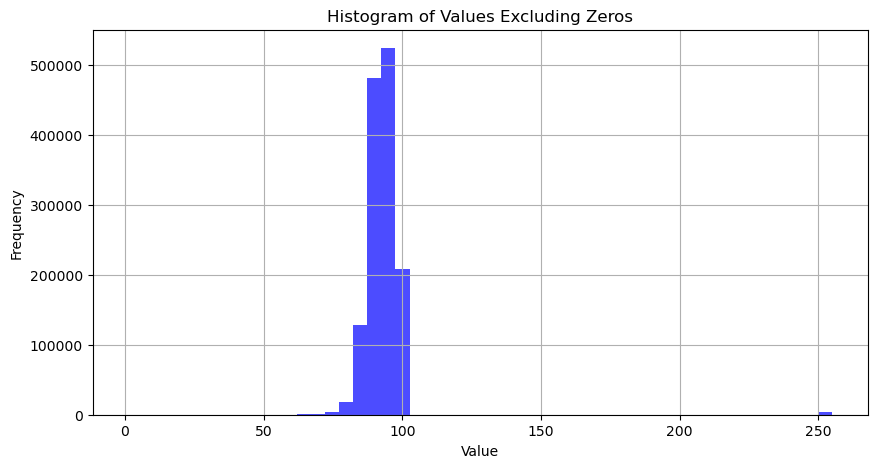

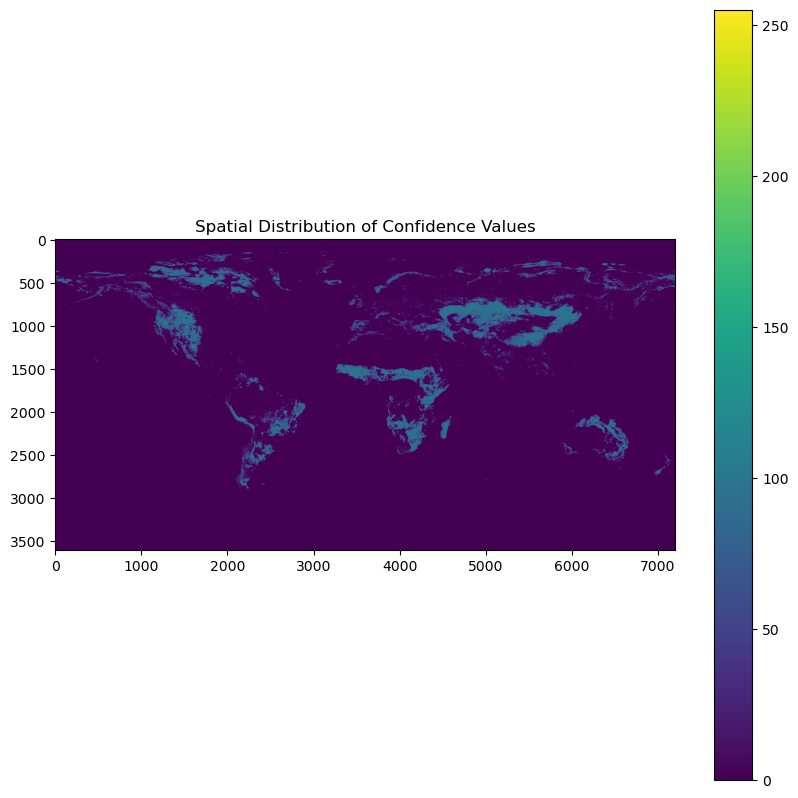

In [20]:
explore_array(confidence_from_grassland_arr)

Basic Statistics:
Mean: 4.8808182767910555
Median: 0.0


c:\Users\zaris\anaconda3\envs\ag-residues\lib\site-packages\numpy\core\fromnumeric.py:745: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Standard Deviation: 20.717530746326425
Min: 0
Max: 99


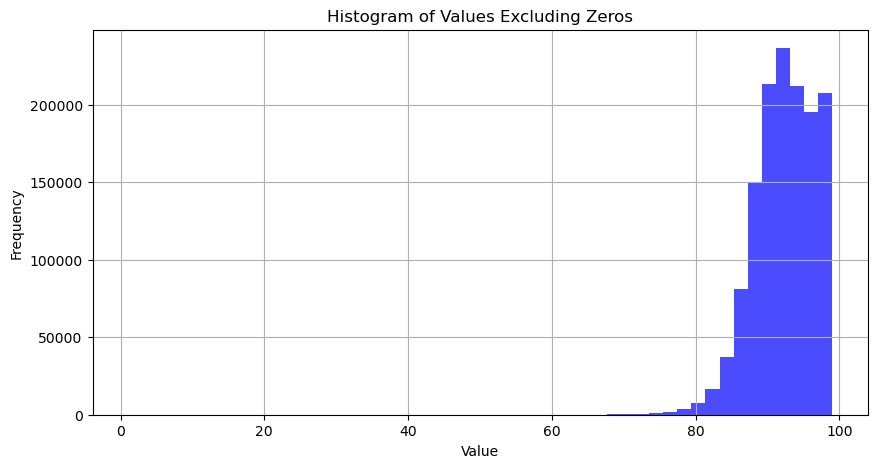

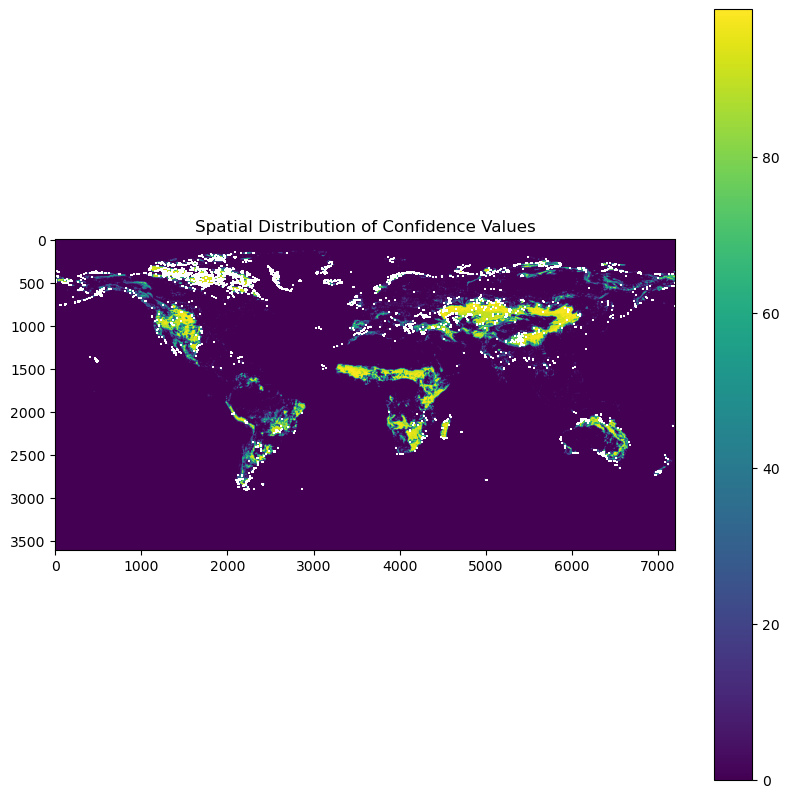

Masked Values Analysis:
Total Masked Values: 4466
Percentage of Masked Values: 0.02%


In [21]:
explore_array(masked_array)

Basic Statistics:
Mean: 0.5240173611111111
Median: 0.0
Standard Deviation: 2.2283580090203445
Min: 0
Max: 10


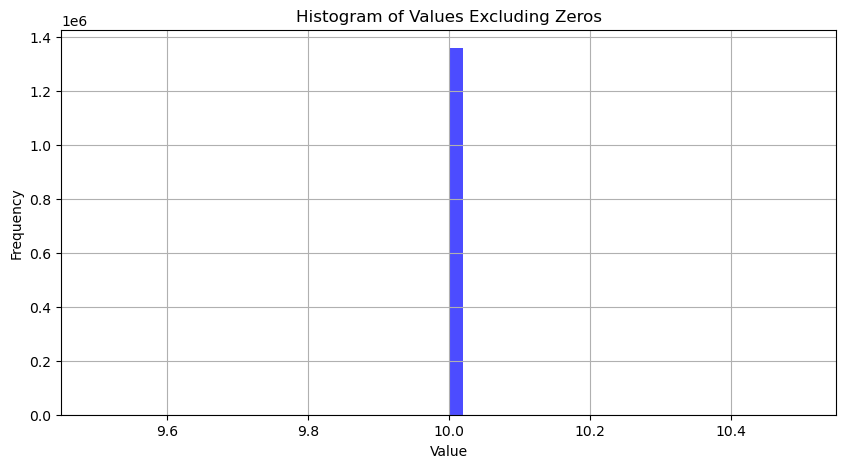

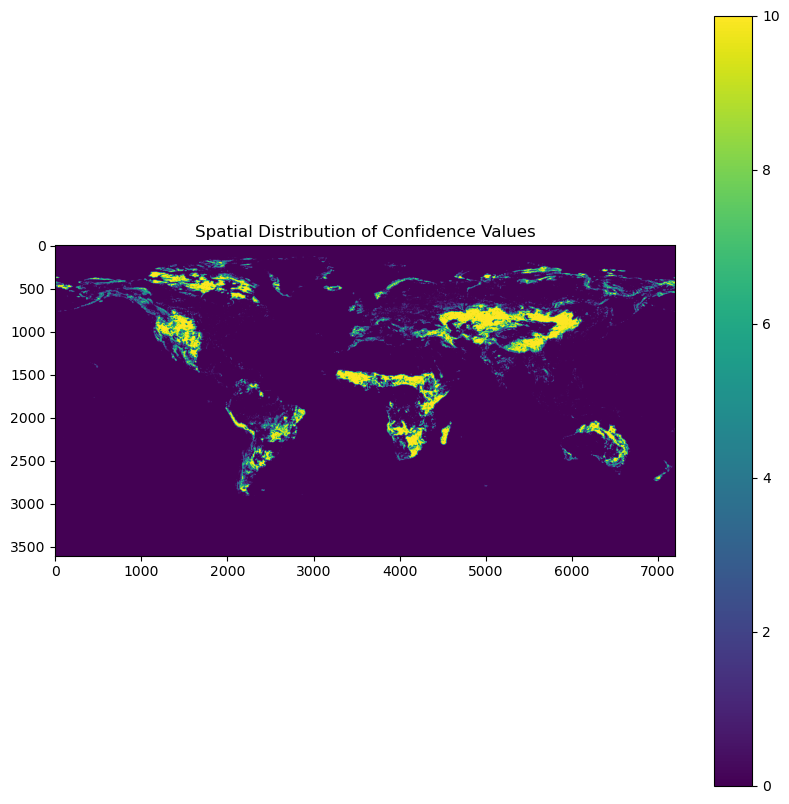

In [22]:
explore_array(high_confidence_landcover)

Basic Statistics:
Mean: 3.5633395447530862
Median: 0.0
Standard Deviation: 5.680884443092836
Min: 0
Max: 16


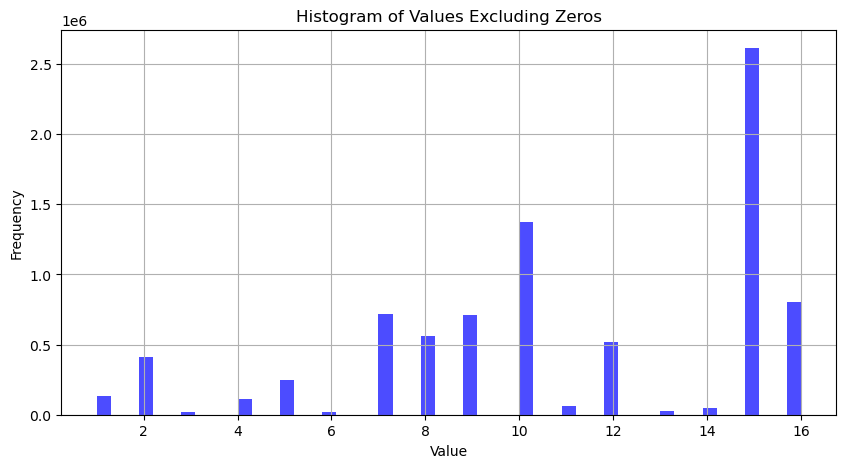

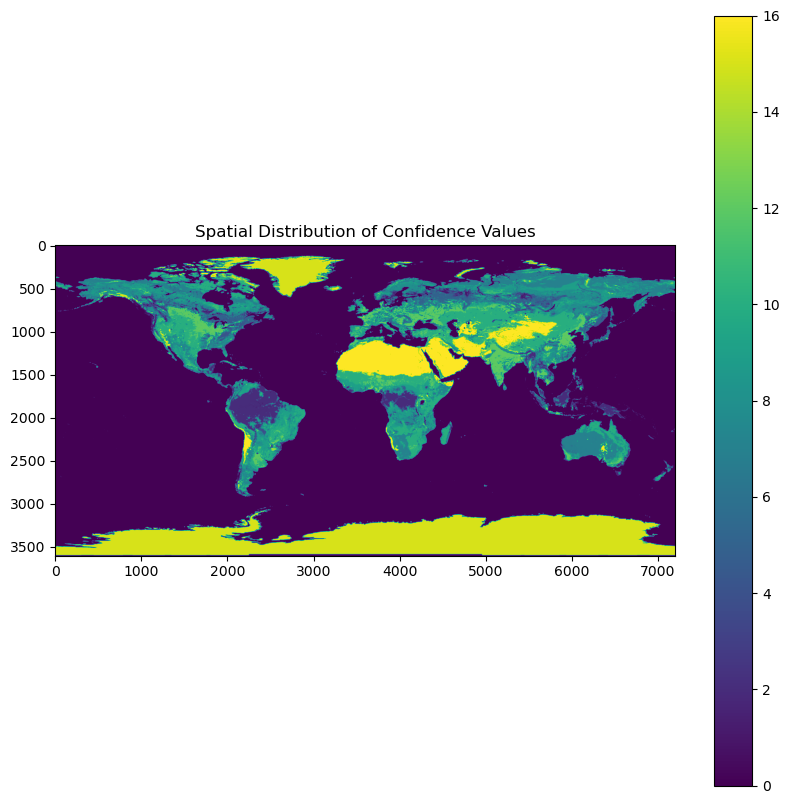

In [23]:
explore_array(landcover_array)